In [19]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv(r"E:\OptiCore_AI\data\processed\merged_energy_weather.csv")

# Remove unwanted columns
df = df.drop(columns=[
'time',
'weather_main',
'weather_description',
'weather_icon',
'hour_y',
'day_y',
'month_y',
'weekday_y',
'is_weekend_y',
'city_name',
'generation hydro pumped storage aggregated',
'forecast wind offshore eday ahead',
'total load forecast'
])

# Remove rows where target is NaN
df = df.dropna(subset=['total load actual'])

# Separate X and y
y = df['total load actual']
X = df.drop(columns=['total load actual'])

# Remove remaining NaN from X
X = X.dropna()

# Align y with X
y = y.loc[X.index]

print("X shape:", X.shape)
print("y shape:", y.shape)


# ---------------------------------------------------------
# Time series split
# split = int(len(X) * 0.8)

# X_train = X[:split]
# X_test = X[split:]

# y_train = y[:split]
# y_test = y[split:]
    #   ........................................
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    print("Train size:", len(X_train))
    print("Test size:", len(X_test))

# -------------------------------------------------------------------

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred)
lr_r2 = r2_score(y_test, y_pred)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression R2:", lr_r2)

X shape: (35971, 44)
y shape: (35971,)
Train size: 5996
Test size: 5995
Train size: 11991
Test size: 5995
Train size: 17986
Test size: 5995
Train size: 23981
Test size: 5995
Train size: 29976
Test size: 5995
Linear Regression MAE: 724.551881766181
Linear Regression R2: 0.9598914197759654


In [20]:
# Random Forest regression model training and evaluation

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 358.6983372208872
Random Forest R2: 0.9862116325775372


In [21]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost R2:", xgb_r2)

XGBoost MAE: 347.6122895381568
XGBoost R2: 0.9872150334340228


In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mae",
    metrics=["mae"]
)

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

nn_pred = model.predict(X_test)



nn_mae = mean_absolute_error(y_test, nn_pred)
nn_r2 = r2_score(y_test, nn_pred)

print("Neural Network MAE:", nn_mae)
print("Neural Network R2:", nn_r2)

Epoch 1/20


e:\OptiCore_AI\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1286.8906 - mae: 1286.8906 - val_loss: 847.5491 - val_mae: 847.5491
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 813.6798 - mae: 813.6798 - val_loss: 777.4993 - val_mae: 777.4993
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 768.8446 - mae: 768.8446 - val_loss: 748.0711 - val_mae: 748.0711
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 738.8613 - mae: 738.8613 - val_loss: 791.7611 - val_mae: 791.7611
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 719.3380 - mae: 719.3380 - val_loss: 743.7244 - val_mae: 743.7244
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 706.8625 - mae: 706.8625 - val_loss: 726.0637 - val_mae: 726.0637
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 679.4648 - mae: 679.4648 - val_loss: 696.1390 - val_mae: 696.1390
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 674.7971 - mae: 674.7971 - val_loss: 684.9651 - val_mae: 684.9651
E

In [23]:
# reshape for lstm model training (samples , timesteps , features)
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        activation="relu",
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])
    )
)

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer="adam",
    loss="mae"
)

lstm_model.fit(
    X_train_lstm,
    y_train,
    epochs=10,
    batch_size=32
)

lstm_pred = lstm_model.predict(X_test_lstm)

lstm_mae = mean_absolute_error(y_test, lstm_pred)
lstm_r2 = r2_score(y_test, lstm_pred)

print("LSTM MAE:", lstm_mae)
print("LSTM R2:", lstm_r2)

Epoch 1/10


e:\OptiCore_AI\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


937/937 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2409.5249
Epoch 2/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 816.7203
Epoch 3/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 799.5839
Epoch 4/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 789.6517
Epoch 5/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 778.4492
Epoch 6/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 774.0456
Epoch 7/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 772.6560
Epoch 8/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 770.6573
Epoch 9/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 765.6066
Epoch 10/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 760.1987
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LSTM MAE: 709.080031210905
LSTM R2: 0.9592909048284354


In [ ]:
#  Hyperparameter Tuning (XGBoost) 

from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1]
}

xgb = XGBRegressor(random_state=42)

grid = GridSearchCV(
    xgb,
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_xgb = grid.best_estimator_

Best Parameters: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400}


In [27]:
best_xgb = grid.best_estimator_

tuned_pred = best_xgb.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_r2 = r2_score(y_test, tuned_pred)

print("Tuned XGBoost MAE:", tuned_mae)
print("Tuned XGBoost R2:", tuned_r2)

Tuned XGBoost MAE: 345.62877984257716
Tuned XGBoost R2: 0.9873864551602128


In [35]:
results = pd.DataFrame({
"Model":[
"Linear Regression",
"Random Forest",
"XGBoost",
"Neural Network",
"LSTM",
"Tuned XGBoost"
],
"MAE":[
lr_mae,
rf_mae,
xgb_mae,
nn_mae,
lstm_mae,
tuned_mae
],
"R2":[
lr_r2,
rf_r2,
xgb_r2,
nn_r2,
lstm_r2,
tuned_r2
]
})

print(results)

               Model         MAE        R2
0  Linear Regression  724.551882  0.959891
1      Random Forest  358.698337  0.986212
2            XGBoost  347.612290  0.987215
3     Neural Network  634.901270  0.966055
4               LSTM  709.080031  0.959291
5      Tuned XGBoost  345.628780  0.987386


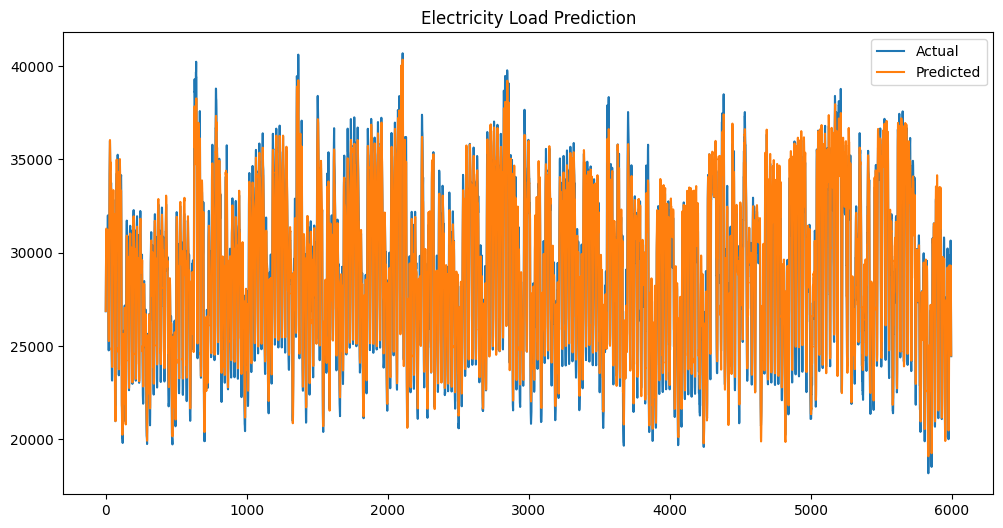

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.legend()
plt.title("Electricity Load Prediction")

plt.show()

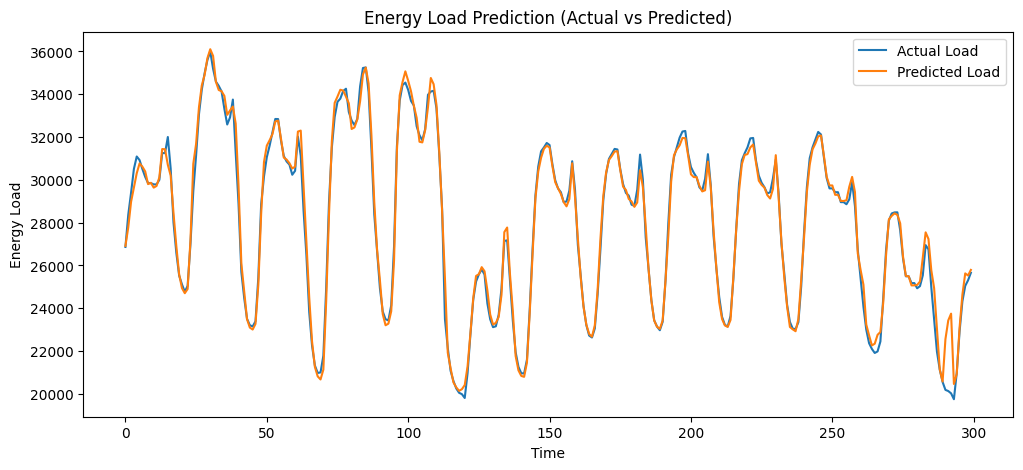

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values[:300], label="Actual Load")
plt.plot(xgb_pred[:300], label="Predicted Load")

plt.legend()
plt.title("Energy Load Prediction (Actual vs Predicted)")
plt.xlabel("Time")
plt.ylabel("Energy Load")

plt.show()

In [30]:
# Feature Importance (Random Forest / XGBoost)

import pandas as pd

importance = pd.Series(
rf_model.feature_importances_,
index=X_train.columns
)

importance = importance.sort_values(ascending=False)

print(importance.head(10))

load_lag_1                                     0.902472
hour_x                                         0.059362
load_lag_24                                    0.011054
forecast solar day ahead                       0.005661
generation hydro pumped storage consumption    0.002715
generation solar                               0.002095
load_lag_168                                   0.001739
generation hydro water reservoir               0.001365
generation fossil oil                          0.001300
generation hydro run-of-river and poundage     0.000979
dtype: float64


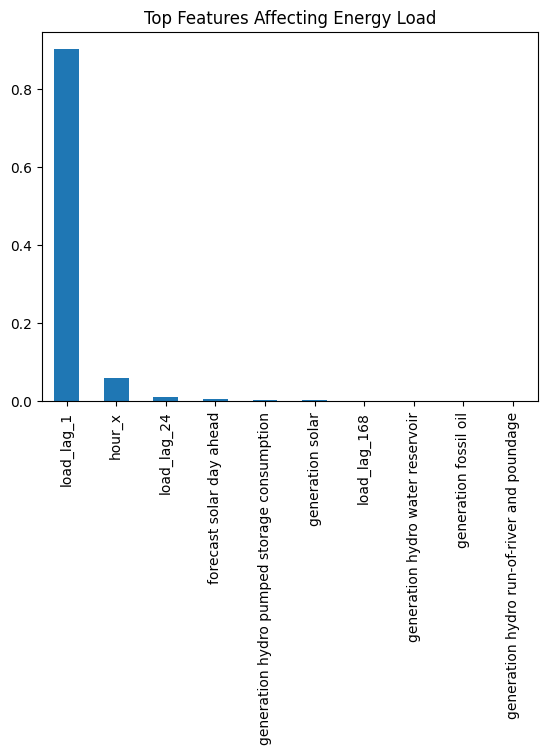

In [31]:
importance.head(10).plot(kind="bar")
plt.title("Top Features Affecting Energy Load")
plt.show()

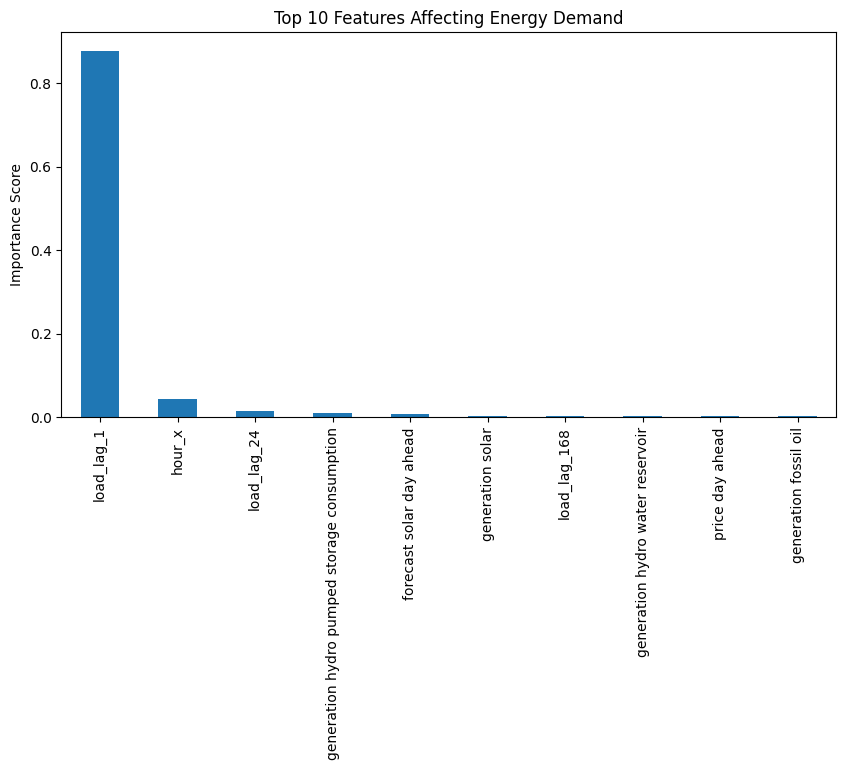

In [32]:
# Feature Importance Plot (XGBoost)
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Features Affecting Energy Demand")
plt.ylabel("Importance Score")
plt.show()

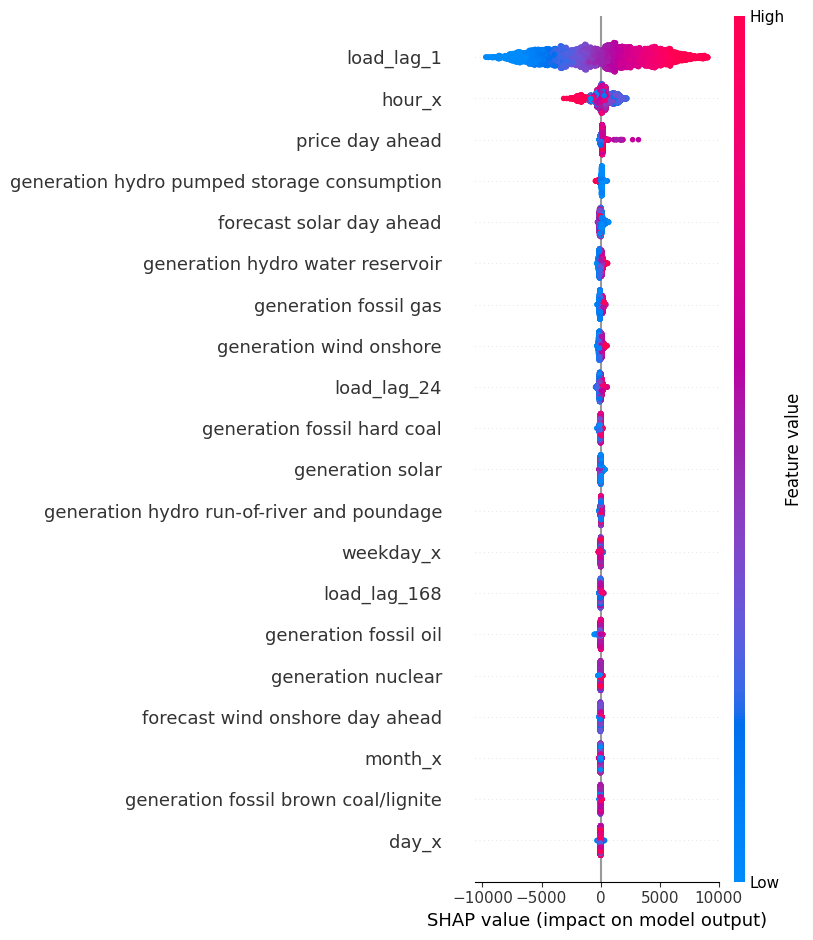

In [ ]:
# SHAP =

# Technique to explain why a machine learning model made a prediction.

import shap

explainer = shap.Explainer(best_xgb)

shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [39]:
# Next 24 Hours Forecast
forecast = pd.DataFrame({
    "Hour": range(1, 25),
    "Predicted_Load": best_xgb.predict(X_test[:24])
})

forecast



,Hour,Predicted_Load
0,1,26898.207031
1,2,27762.082031
2,3,28991.964844
3,4,29698.503906
4,5,30316.318359
5,6,30766.574219
6,7,30638.300781
7,8,30401.890625
8,9,29790.695312
9,10,29847.445312


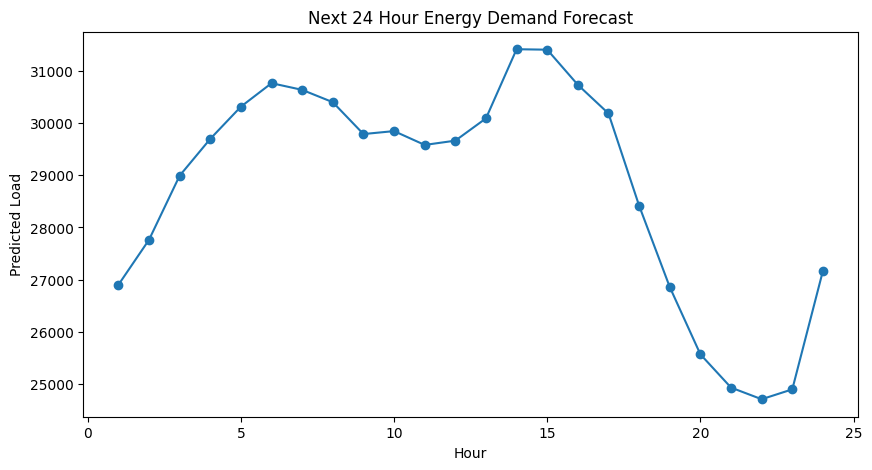

In [40]:
# visualization = forecast.head(24)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(forecast["Hour"], forecast["Predicted_Load"], marker="o")

plt.title("Next 24 Hour Energy Demand Forecast")
plt.xlabel("Hour")
plt.ylabel("Predicted Load")
plt.show()

In [33]:
# import os
# import joblib

# os.makedirs("models", exist_ok=True)

# joblib.dump(xgb_model, "models/xgboost_energy_model_v1.pkl")
# joblib.dump(best_xgb, "models/xgboost_energy_model_v2.pkl")